In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.svm import SVC

# 1. Изучение примеров
Перед началом выполнения лабораторной работы я изучил предложенные примеры

# 2. Загрузка и подготовка данных

In [2]:
data = pd.read_csv('D:/Python/OmGTU/ML/data/post_card_transdata.csv').drop(columns=['Unnamed: 0'])
data.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1,1,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0
3,2.247564,5.600044,0.362663,1,1,0,1,0
4,44.190936,0.566486,2.222767,1,1,0,1,0


In [3]:
X = data.drop(columns=['fraud'])
X

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
0,57.877857,0.311140,1.945940,1,1,0,0
1,10.829943,0.175592,1.294219,1,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1
3,2.247564,5.600044,0.362663,1,1,0,1
4,44.190936,0.566486,2.222767,1,1,0,1
...,...,...,...,...,...,...,...
999995,2.207101,0.112651,1.626798,1,1,0,0
999996,19.872726,2.683904,2.778303,1,1,0,0
999997,2.914857,1.472687,0.218075,1,1,0,1
999998,4.258729,0.242023,0.475822,1,0,0,1


In [4]:
y = data['fraud']
y

0         0
1         0
2         0
3         0
4         0
         ..
999995    0
999996    0
999997    0
999998    0
999999    0
Name: fraud, Length: 1000000, dtype: int64

Задача на **бинарную** классификацию 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

In [7]:
Counter(y_train)

Counter({0: 730078, 1: 69922})

In [8]:
X_train_sb, y_train_b = SMOTE(random_state=42).fit_resample(X_train, y_train)

In [9]:
Counter(y_train_b)

Counter({0: 730078, 1: 730078})

In [10]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
data_dict = {'X_train': X_train,
          'X_test': X_test,
          'y_train': y_train,
          'y_test': y_test,
          'X_train_s': X_train_s,
          'X_train_sb': X_train_sb,
          'y_train_b': y_train_b}


for name, selection in data_dict.items():
    print(f'{name}: {selection.shape}')
    if 'y' in name: print(Counter(selection))

X_train: (800000, 7)
X_test: (200000, 7)
y_train: (800000,)
Counter({0: 730078, 1: 69922})
y_test: (200000,)
Counter({0: 182519, 1: 17481})
X_train_s: (800000, 7)
X_train_sb: (1460156, 7)
y_train_b: (1460156,)
Counter({0: 730078, 1: 730078})


# 3. Решение задачи классификации

### Logit

In [12]:
model_logit = LogisticRegression(C=1.1, random_state=42, n_jobs=-1)
model_logit.fit(X_train_sb, y_train_b)

LogisticRegression(C=1.1, n_jobs=-1, random_state=42)

In [13]:
y_pred = model_logit.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
accuracy_score(y_test, y_pred)

[[170827  11692]
 [   905  16576]]
              precision    recall  f1-score   support

           0       0.99      0.94      0.96    182519
           1       0.59      0.95      0.72     17481

    accuracy                           0.94    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.94      0.94    200000



0.937015

In [14]:
y_pred = model_logit.predict(X_train_sb)
print(confusion_matrix(y_train_b, y_pred))
print(classification_report(y_train_b, y_pred))
accuracy_score(y_train_b, y_pred)

[[682516  47562]
 [ 35526 694552]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94    730078
           1       0.94      0.95      0.94    730078

    accuracy                           0.94   1460156
   macro avg       0.94      0.94      0.94   1460156
weighted avg       0.94      0.94      0.94   1460156



0.9430964910598594

In [15]:
score = cross_val_score(model_logit, X, y, cv=kf, scoring="accuracy", n_jobs=-1)
score

array([0.95899 , 0.95719 , 0.95819 , 0.959095, 0.956935])

### kNN

In [16]:
model_knn = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
model_knn.fit(X_train_sb, y_train_b)

KNeighborsClassifier(n_jobs=-1, n_neighbors=15, weights='distance')

In [17]:
y_pred = model_knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
accuracy_score(y_test, y_pred)

[[175880   6639]
 [    61  17420]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    182519
           1       0.72      1.00      0.84     17481

    accuracy                           0.97    200000
   macro avg       0.86      0.98      0.91    200000
weighted avg       0.98      0.97      0.97    200000



0.9665

In [18]:
score = cross_val_score(model_knn, X, y, cv=kf, scoring="accuracy", n_jobs=-1)
score

array([0.98324 , 0.983875, 0.98391 , 0.983405, 0.98301 ])

### Naive Bayes

In [19]:
model_naive = GaussianNB(var_smoothing=0.00002)
model_naive.fit(X_train_sb, y_train_b)

GaussianNB(var_smoothing=2e-05)

In [20]:
y_pred = model_naive.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
accuracy_score(y_test, y_pred)

[[175923   6596]
 [  6501  10980]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96    182519
           1       0.62      0.63      0.63     17481

    accuracy                           0.93    200000
   macro avg       0.79      0.80      0.80    200000
weighted avg       0.93      0.93      0.93    200000



0.934515

In [21]:
y_pred = model_naive.predict(X_train_sb)
print(confusion_matrix(y_train_b, y_pred))
print(classification_report(y_train_b, y_pred))
accuracy_score(y_train_b, y_pred)

[[703686  26392]
 [275011 455067]]
              precision    recall  f1-score   support

           0       0.72      0.96      0.82    730078
           1       0.95      0.62      0.75    730078

    accuracy                           0.79   1460156
   macro avg       0.83      0.79      0.79   1460156
weighted avg       0.83      0.79      0.79   1460156



0.7935816447009771

In [22]:
score = cross_val_score(model_naive, X, y, cv=kf, scoring="accuracy", n_jobs=-1)
score

array([0.927925, 0.92938 , 0.928775, 0.93002 , 0.92929 ])

### SVC

Частный случай моей задачи (конкретные данные) очень слабо подходят под концепцию алгоритма SVC, так как данных много и вычислить "опорные вектора" очень сложно. Для реботы с SVC отберу часть выборки из всех данных.

In [23]:
rus = RandomUnderSampler(random_state=42)

_, X_sample, _, y_sample = train_test_split(X_train, y_train, test_size=0.5, stratify=y_train, random_state=42)
X_train_res_svc, y_train_res_svc = rus.fit_resample(X_sample, y_sample)

_, X_sample, _, y_sample = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)
X_test_res_svc, y_test_res_svc = rus.fit_resample(X_sample, y_sample)

X_train_res_svc.shape, X_test_res_svc.shape

((69922, 7), (17480, 7))

In [24]:
model_svc = SVC(gamma=0.1)
model_svc.fit(X_train_res_svc, y_train_res_svc)

SVC(gamma=0.1)

In [25]:
y_pred = model_svc.predict(X_test_res_svc)
print(confusion_matrix(y_test_res_svc, y_pred))
print(classification_report(y_test_res_svc, y_pred))
accuracy_score(y_test_res_svc, y_pred)

[[8350  390]
 [   6 8734]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      8740
           1       0.96      1.00      0.98      8740

    accuracy                           0.98     17480
   macro avg       0.98      0.98      0.98     17480
weighted avg       0.98      0.98      0.98     17480



0.977345537757437

In [26]:
y_pred = model_svc.predict(X_train_res_svc)
print(confusion_matrix(y_train_res_svc, y_pred))
print(classification_report(y_train_res_svc, y_pred))
accuracy_score(y_train_res_svc, y_pred)

[[33630  1331]
 [    1 34960]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     34961
           1       0.96      1.00      0.98     34961

    accuracy                           0.98     69922
   macro avg       0.98      0.98      0.98     69922
weighted avg       0.98      0.98      0.98     69922



0.9809502016532707

### Tree

In [27]:
model_tree = DecisionTreeClassifier(min_samples_split=5, max_depth=7, criterion='entropy', class_weight='balanced', random_state=42)
model_tree.fit(X_train_sb, y_train_b)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, min_samples_split=5, random_state=42)

In [28]:
y_pred = model_tree.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
accuracy_score(y_test, y_pred)

[[182392    127]
 [     3  17478]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    182519
           1       0.99      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



0.99935

## Объединение моделей

In [29]:
models = {'Logit': model_logit,
          'kNN': model_knn,
          'Naive Bayes': model_naive,
          'SVC': model_svc,
          'Tree': model_tree}

# 4. Визуализация

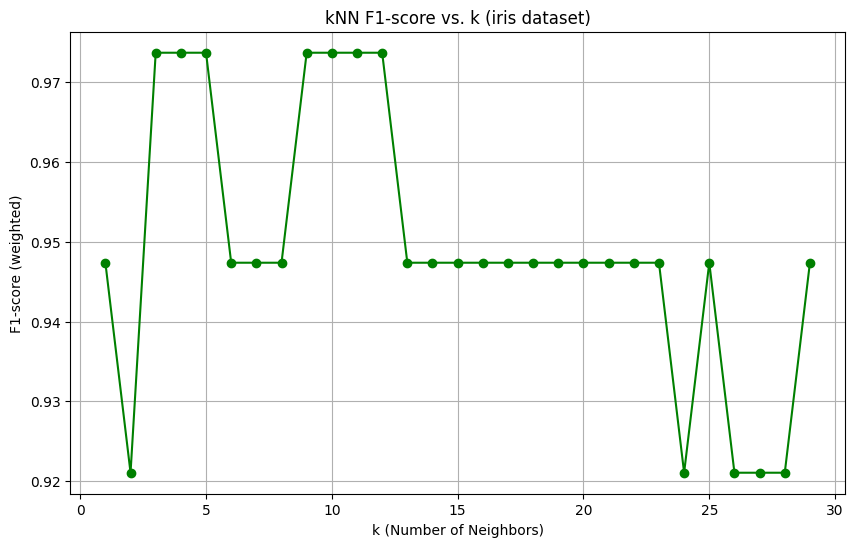

In [30]:
iris = load_iris()
demo_X = iris.data
demo_y = iris.target

demo_X_train, demo_X_test, demo_y_train, demo_y_test = train_test_split(
    demo_X, demo_y, 
    stratify=demo_y, 
    random_state=42
)

k_values = range(1, 30)
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(demo_X_train, demo_y_train)
    y_pred = knn.predict(demo_X_test)
    f1 = f1_score(demo_y_test, y_pred, average='micro')
    f1_scores.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(k_values, f1_scores, marker='o', color='green')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('F1-score (weighted)')
plt.title('kNN F1-score vs. k (iris dataset)')
plt.grid()
plt.show()

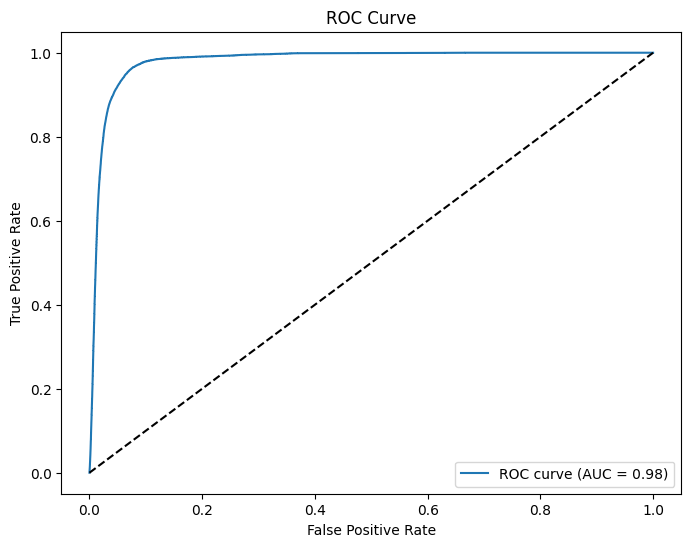

In [31]:
y_scores = model_logit.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

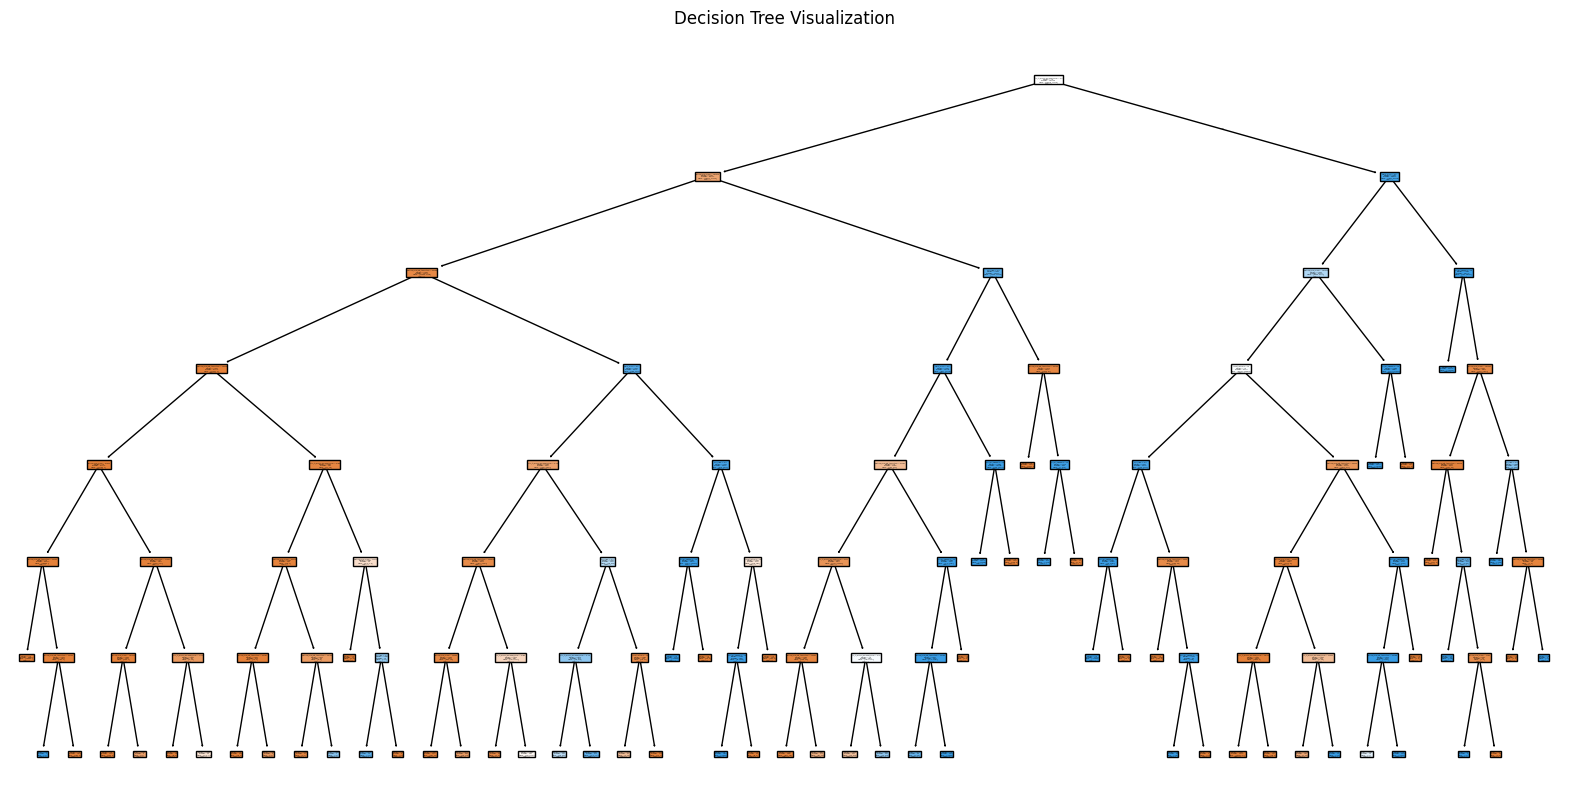

In [32]:
plt.figure(figsize=(20, 10))
plot_tree(model_tree, filled=True, feature_names=X_train.columns, class_names=['0', '1'])
plt.title('Decision Tree Visualization')
plt.show()

# 5. Оценка качества моделей

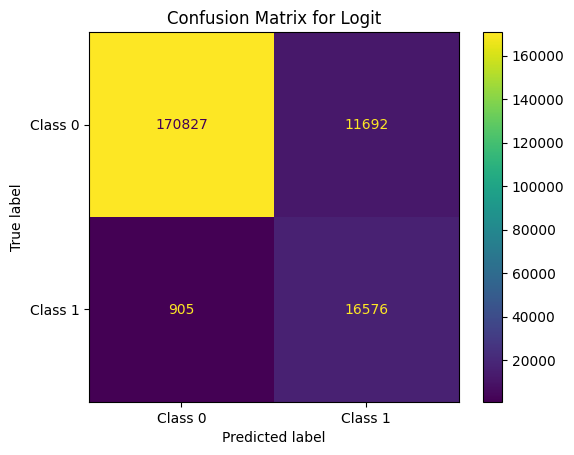

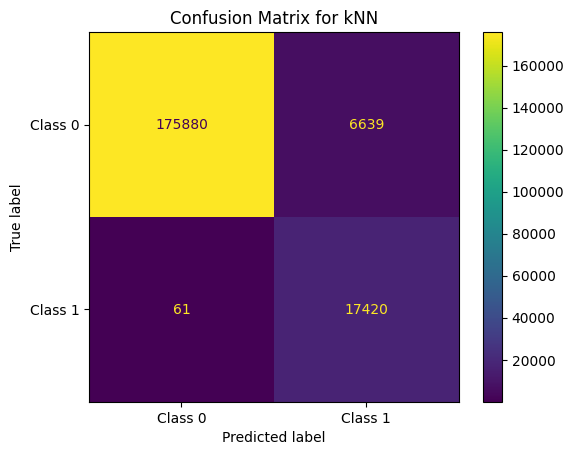

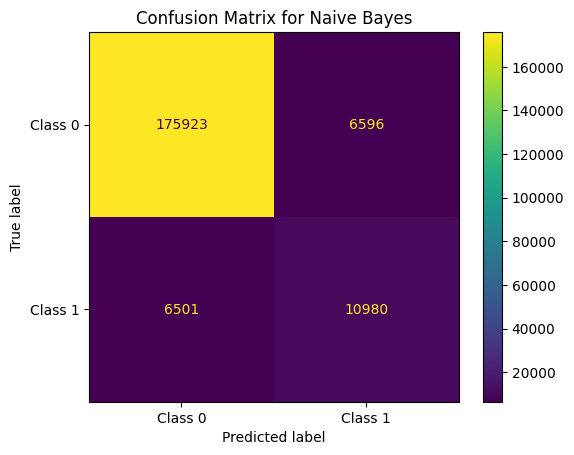

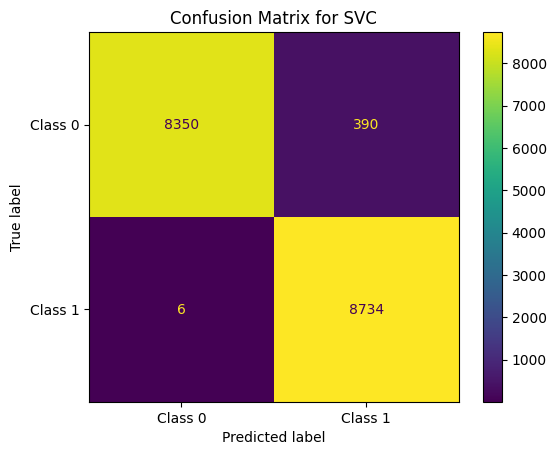

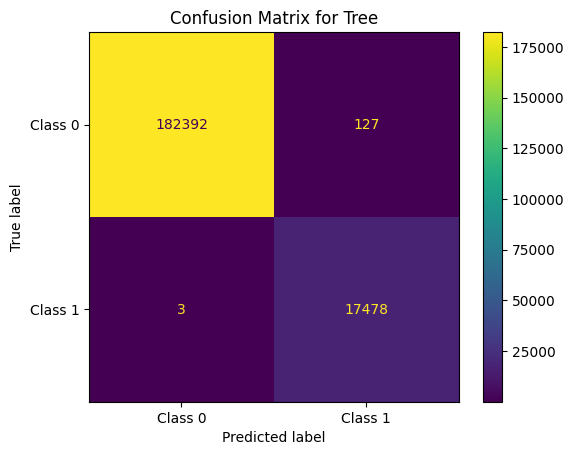

In [33]:
for name, model in models.items():
    if name == 'SVC':
        y_pred = model.predict(X_test_res_svc)
        cm = confusion_matrix(y_test_res_svc, y_pred)
    else:
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1'])
    disp.plot()
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

# 6. Реализация пользовательских функций

In [34]:
from funcs.metrics import *

# 7. Реализация алгоритма классификатора kNN

In [35]:
from algorythms.knn import *

In [36]:
rus = RandomUnderSampler(random_state=42)

_, X_sample, _, y_sample = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_sample, y_sample)

_, X_sample, _, y_sample = train_test_split(X_test, y_test, test_size=0.1, stratify=y_test, random_state=42)
X_test_res, y_test_res = rus.fit_resample(X_sample, y_sample)

X_train_res.shape, X_test_res.shape

((13984, 7), (3496, 7))

In [37]:
model_knn_custom = SimpleKNN(15)
model_knn_custom.fit(X_train_res, y_train_res)

In [38]:
y_pred = model_knn_custom.predict(X_train_res)
print(confusion_matrix(y_train_res, y_pred))
print(classification_report(y_train_res, y_pred))
accuracy_score(y_train_res, y_pred)

[[6286  706]
 [  54 6938]]
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      6992
           1       0.91      0.99      0.95      6992

    accuracy                           0.95     13984
   macro avg       0.95      0.95      0.95     13984
weighted avg       0.95      0.95      0.95     13984



0.9456521739130435

In [39]:
y_pred = model_knn_custom.predict(X_test_res)
print(confusion_matrix(y_test_res, y_pred))
print(classification_report(y_test_res, y_pred))
accuracy_score(y_test_res, y_pred)

[[1576  172]
 [  16 1732]]
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1748
           1       0.91      0.99      0.95      1748

    accuracy                           0.95      3496
   macro avg       0.95      0.95      0.95      3496
weighted avg       0.95      0.95      0.95      3496



0.9462242562929062

In [40]:
model_knn_simple = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
model_knn_simple.fit(X_train_res, y_train_res)

knn_models = {'sklearn kNN': model_knn_simple, 'my kNN': model_knn_custom}

def calculate_metrics(y_true, y_pred):
    return {
        'F1': round(f1_score(y_true, y_pred), 2),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4)
    }

results = []

for model_name, model in knn_models.items():

    train_pred = model.predict(X_train_res)
    test_pred = model.predict(X_test_res)

    train_metrics = calculate_metrics(y_train_res, train_pred)
    test_metrics = calculate_metrics(y_test_res, test_pred)

    result_row = {'Model': model_name}

    for metric, value in train_metrics.items():
        result_row[f'Train {metric}'] = value

    for metric, value in test_metrics.items():
        result_row[f'Test {metric}'] = value
    
    results.append(result_row)

df = pd.DataFrame(results)
metric_order = ['F1', 'Accuracy', 'Precision', 'Recall']
columns_order = ['Model'] + [f'Train {m}' for m in metric_order] + [f'Test {m}' for m in metric_order]
df = df[columns_order]
df

,Model,Train F1,Train Accuracy,Train Precision,Train Recall,Test F1,Test Accuracy,Test Precision,Test Recall
0,sklearn kNN,1.00,1.0000,1.0000,1.0000,0.95,0.9482,0.9117,0.9926
1,my kNN,0.95,0.9457,0.9076,0.9923,0.95,0.9462,0.9097,0.9908


# 8. Создание таблиц результатов

In [41]:
results = []
for model_name, model in models.items():
    if name == 'SVC':
        y_pred = model.predict(X_test_res_svc)
        y_true = y_test_res_svc
    else:
        y_pred = model.predict(X_test)
        y_true = y_test

    sk_metrics = {
        'sk_F1': round(f1_score(y_true, y_pred, average='micro'), 2),
        'sk_Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'sk_Precision': round(precision_score(y_true, y_pred, average='micro'), 4),
        'sk_Recall': round(recall_score(y_true, y_pred, average='micro'), 4)
    }

    my_metrics = {
        'my_F1': round(f1(y_true, y_pred, average='micro'), 2),
        'my_Accuracy': round(accuracy(y_true, y_pred), 4),
        'my_Precision': round(precision(y_true, y_pred, average='micro'), 4),
        'my_Recall': round(recall(y_true, y_pred, average='micro'), 4)
    }
    
    results.append({'Model': model_name} | sk_metrics | my_metrics)

df = pd.DataFrame(results)

metric_types = ['F1', 'Accuracy', 'Precision', 'Recall']
columns = ['Model'] + [f'sk_{m}' for m in metric_types] + [f'my_{m}' for m in metric_types]
df = df[columns]
df

,Model,sk_F1,sk_Accuracy,sk_Precision,sk_Recall,my_F1,my_Accuracy,my_Precision,my_Recall
0,Logit,0.94,0.9370,0.9370,0.9370,0.94,0.9370,0.9370,0.9370
1,kNN,0.97,0.9665,0.9665,0.9665,0.97,0.9665,0.9665,0.9665
2,Naive Bayes,0.93,0.9345,0.9345,0.9345,0.93,0.9345,0.9345,0.9345
3,SVC,0.96,0.9563,0.9563,0.9563,0.96,0.9563,0.9563,0.9563
4,Tree,1.00,0.9993,0.9993,0.9993,1.00,0.9994,0.9994,0.9994


In [42]:
models = {
    'Logit': LogisticRegression(C=1.1, random_state=42, n_jobs=-1),
    'kNN': KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1), 
    'Naive Bayes': GaussianNB(var_smoothing=0.00002),
    'SVC': SVC(gamma=0.1),
    'Tree': DecisionTreeClassifier(min_samples_split=5, max_depth=7, criterion='entropy', class_weight='balanced', random_state=42)
}

results = []
for name, model in models.items():
    if name == 'SVC':
        model.fit(X_train_res_svc, y_train_res_svc)
        y_pred = model.predict(X_test_res_svc)
        y_true = y_test_res_svc
    else:
        model.fit(X_train_sb, y_train_b)
        y_pred = model.predict(X_test)
        y_true = y_test

    holdout_metrics = calculate_metrics(y_true, y_pred)

    if name == 'SVC':
        cv_results = cross_validate(
        model, X_train_res_svc, y_train_res_svc, cv=kf,
        scoring={
            'F1': 'f1_macro',
            'Accuracy': 'accuracy', 
            'Precision': 'precision_macro',
            'Recall': 'recall_macro'
        }
    )

    else:
        cv_results = cross_validate(
            model, X, y, cv=kf,
            scoring={
                'F1': 'f1_macro',
                'Accuracy': 'accuracy', 
                'Precision': 'precision_macro',
                'Recall': 'recall_macro'
            }
        )

    kfold_metrics = {
        'F1': round(np.mean(cv_results['test_F1']), 2),
        'Accuracy': round(np.mean(cv_results['test_Accuracy']), 4),
        'Precision': round(np.mean(cv_results['test_Precision']), 4),
        'Recall': round(np.mean(cv_results['test_Recall']), 4)
    }
    
    results.append({
        'Model': name,
        **{f'HoldOut {k}': v for k, v in holdout_metrics.items()},
        **{f'KFold {k}': v for k, v in kfold_metrics.items()}
    })

metric_order = ['F1', 'Accuracy', 'Precision', 'Recall']
df = pd.DataFrame(results)[
    ['Model'] + 
    [f'HoldOut {m}' for m in metric_order] + 
    [f'KFold {m}' for m in metric_order]
]

df

,Model,HoldOut F1,HoldOut Accuracy,HoldOut Precision,HoldOut Recall,KFold F1,KFold Accuracy,KFold Precision,KFold Recall
0,Logit,0.72,0.9370,0.5864,0.9482,0.84,0.9581,0.9264,0.7931
1,kNN,0.84,0.9665,0.7241,0.9965,0.95,0.9835,0.9433,0.9547
2,Naive Bayes,0.63,0.9345,0.6247,0.6281,0.73,0.9291,0.7980,0.6929
3,SVC,0.98,0.9773,0.9573,0.9993,0.97,0.9734,0.9747,0.9734
4,Tree,1.00,0.9993,0.9928,0.9998,1.00,1.0000,1.0000,1.0000


# 9. Вывод

На этих данных очень сложно решить задачу классификации предложенными способами, но лучшей моделью из предложенных является kNN (F1 показатель наивысший среди моделей (0.95 для StratifyKFold), то есть среднее гармоническое между precision и recall, что даёт более корректную оценку точности, чем accuracy). То есть kNN работает долго, но достаточно точно определяет как 0 класс, так и 1, тогда как другие модели просто чаще определяют класс 0, от чего accuracy высокий, а вот F1 - низкий.

Почему лучший алгоритм не SVC? Так как данных очень много, а SVC очень медленный алгоритм при больших данных мне пришлось уменьшить выборку для его рассмотрения. Я не готов утверждать, что на полной выборке SVC будет работать так же успешно, как на маленькой, а kNN обучался на полной выборке, из чего следует уверенность в его качестве.